In [4]:
from astropy.io import fits
import numpy as np
from matplotlib import pyplot as plt

In [58]:
filter = 'F158'

with fits.open(f'roman_psfs/psf_{filter}.fits') as hdul:
    data = hdul[0].data

In [59]:
mag_5_sig_depths_single_pass = {'F106': 26.1, 'F129': 26.0, 'F158': 26.0}
mag_5_sig_depths_full_survey = {'F106': 26.5, 'F129': 26.4, 'F158': 26.4}

flux_1_sig_depth_single_pass = 10**(-0.4 * (mag_5_sig_depths_single_pass[filter])) * 3631 / 5
flux_1_sig_depth_full_survey = 10**(-0.4 * (mag_5_sig_depths_full_survey[filter])) * 3631 / 5

In [60]:
data.shape

(184, 184)

In [61]:
# generate a normalized gaussian PSF such that S is the same as the Roman PSF
psf_normalized = data / np.sum(data)

gaussian_psf = np.exp(-0.5 * (np.arange(-10, 11)**2 + np.arange(-10, 11)[:, None]**2) / 1.5**2)
gaussian_psf /= np.sum(gaussian_psf)

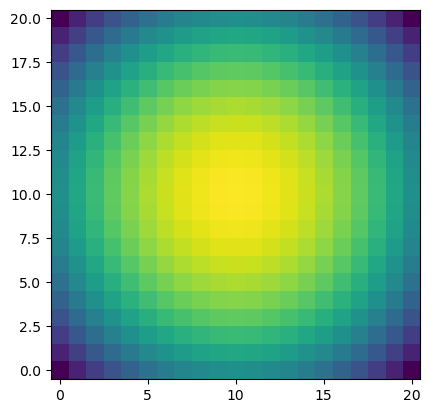

In [62]:
plt.imshow(np.log10(gaussian_psf), origin='lower')

In [63]:
# Calculate S for both PSFs
S_roman = np.sum(psf_normalized**2)
S_gaussian = np.sum(gaussian_psf**2)

print(f"Roman PSF: S = {S_roman:.6f}")
print(f"Gaussian PSF: S = {S_gaussian:.6f}")
print(f"\nTo match Roman's S, we need to adjust the Gaussian sigma...")

Roman PSF: S = 0.008382
Gaussian PSF: S = 0.035368

To match Roman's S, we need to adjust the Gaussian sigma...


In [64]:
# Create a Gaussian PSF on the same grid as Roman PSF to match S
# For a 2D Gaussian PSF: S ≈ 1 / (2π σ²) for well-sampled PSFs
# We'll iteratively find the sigma that gives us the same S

from scipy.optimize import fsolve

def gaussian_psf_2d(sigma, shape):
    """Generate a 2D Gaussian PSF with given sigma"""
    center = (shape[0]//2, shape[1]//2)
    y, x = np.ogrid[:shape[0], :shape[1]]
    r2 = (x - center[1])**2 + (y - center[0])**2
    psf = np.exp(-r2 / (2 * sigma**2))
    psf /= np.sum(psf)  # Normalize
    return psf

def s_difference(sigma, target_s, shape):
    """Function to minimize: difference between S values"""
    psf = gaussian_psf_2d(sigma, shape)
    s_current = np.sum(psf**2)
    return s_current - target_s

# Find the sigma that gives us the same S as Roman PSF
sigma_initial = 2.0
sigma_matched = fsolve(s_difference, sigma_initial, args=(S_roman, psf_normalized.shape))[0]

# Create the matched Gaussian PSF
gaussian_psf_matched = gaussian_psf_2d(sigma_matched, psf_normalized.shape)
S_gaussian_matched = np.sum(gaussian_psf_matched**2)

print(f"Target S (Roman): {S_roman:.6f}")
print(f"Gaussian sigma needed: {sigma_matched:.3f} pixels")
print(f"Achieved S (Gaussian): {S_gaussian_matched:.6f}")
print(f"Difference: {abs(S_gaussian_matched - S_roman):.2e}")

Target S (Roman): 0.008382
Gaussian sigma needed: 3.081 pixels
Achieved S (Gaussian): 0.008382
Difference: 3.47e-18


/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_2987/1857695285.py:13: RuntimeWarning: divide by zero encountered in log10
  im2 = axes[0, 1].imshow(np.log10(gaussian_psf_matched), origin='lower', vmin=vmin, vmax=vmax)
/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_2987/1857695285.py:18: RuntimeWarning: divide by zero encountered in log10
  diff = np.log10(np.abs(psf_normalized)) - np.log10(gaussian_psf_matched)


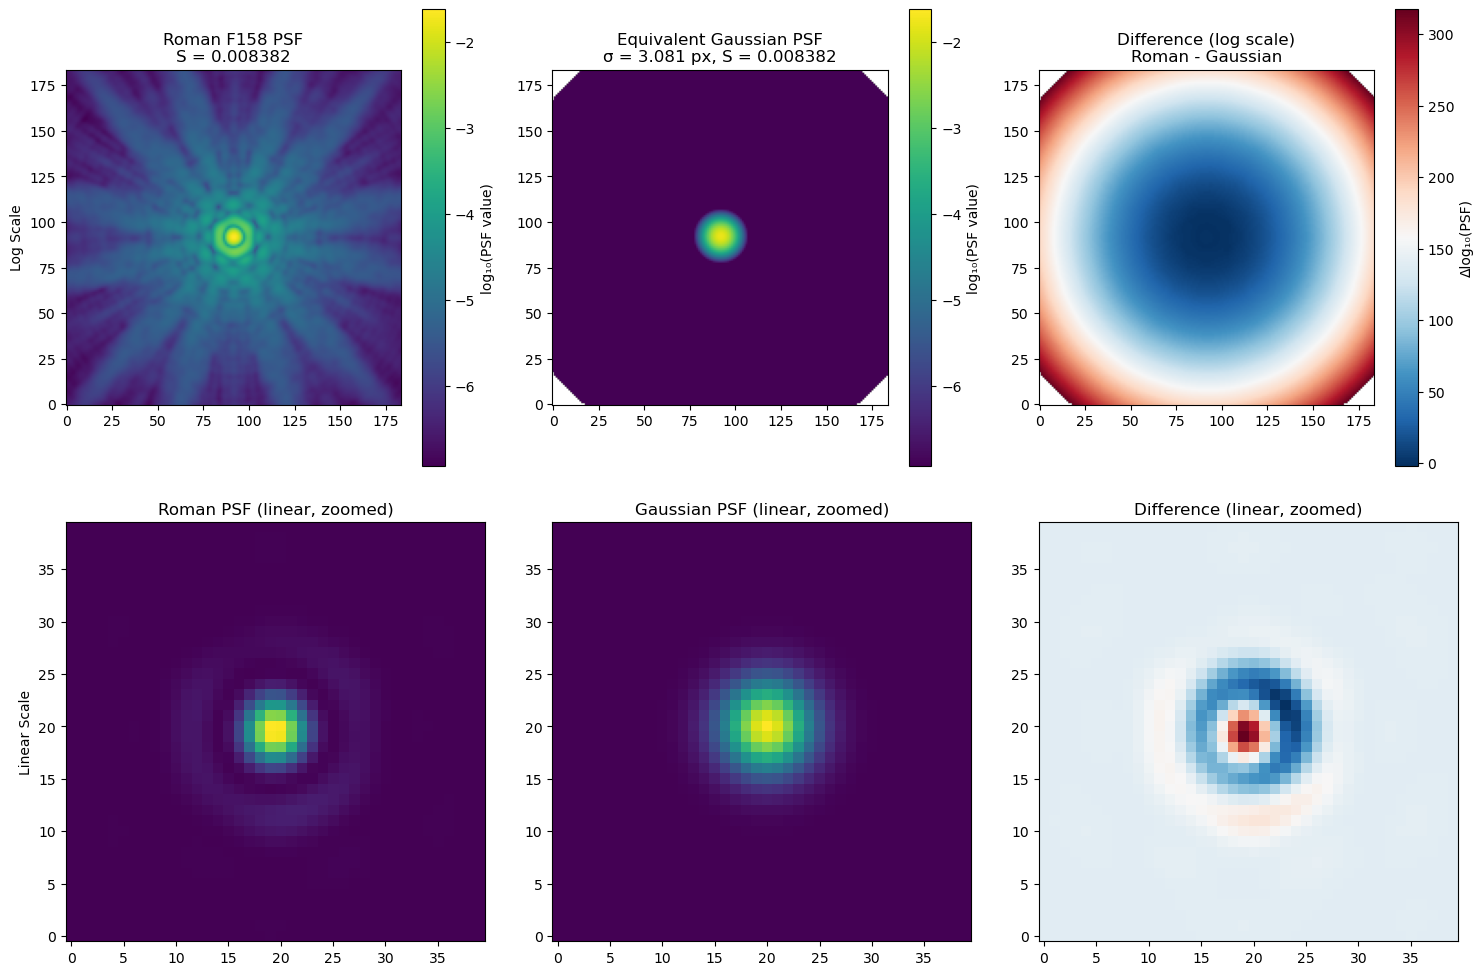

In [65]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Log-scale images
vmin = np.log10(np.abs(psf_normalized[psf_normalized > 0].min()))
vmax = np.log10(np.abs(psf_normalized.max()))

im1 = axes[0, 0].imshow(np.log10(np.abs(psf_normalized)), origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f'Roman {filter} PSF\nS = {S_roman:.6f}')
axes[0, 0].set_ylabel('Log Scale')
plt.colorbar(im1, ax=axes[0, 0], label='log₁₀(PSF value)')

im2 = axes[0, 1].imshow(np.log10(gaussian_psf_matched), origin='lower', vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f'Equivalent Gaussian PSF\nσ = {sigma_matched:.3f} px, S = {S_gaussian_matched:.6f}')
plt.colorbar(im2, ax=axes[0, 1], label='log₁₀(PSF value)')

# Difference
diff = np.log10(np.abs(psf_normalized)) - np.log10(gaussian_psf_matched)
im3 = axes[0, 2].imshow(diff, origin='lower', cmap='RdBu_r')
axes[0, 2].set_title('Difference (log scale)\nRoman - Gaussian')
plt.colorbar(im3, ax=axes[0, 2], label='Δlog₁₀(PSF)')

# Row 2: Linear scale (central region)
center = psf_normalized.shape[0] // 2
zoom = 20
slc = slice(center-zoom, center+zoom)

axes[1, 0].imshow(psf_normalized[slc, slc], origin='lower')
axes[1, 0].set_title('Roman PSF (linear, zoomed)')
axes[1, 0].set_ylabel('Linear Scale')

axes[1, 1].imshow(gaussian_psf_matched[slc, slc], origin='lower')
axes[1, 1].set_title('Gaussian PSF (linear, zoomed)')

axes[1, 2].imshow(psf_normalized[slc, slc] - gaussian_psf_matched[slc, slc], 
                  origin='lower', cmap='RdBu_r')
axes[1, 2].set_title('Difference (linear, zoomed)')

plt.tight_layout()
plt.show()

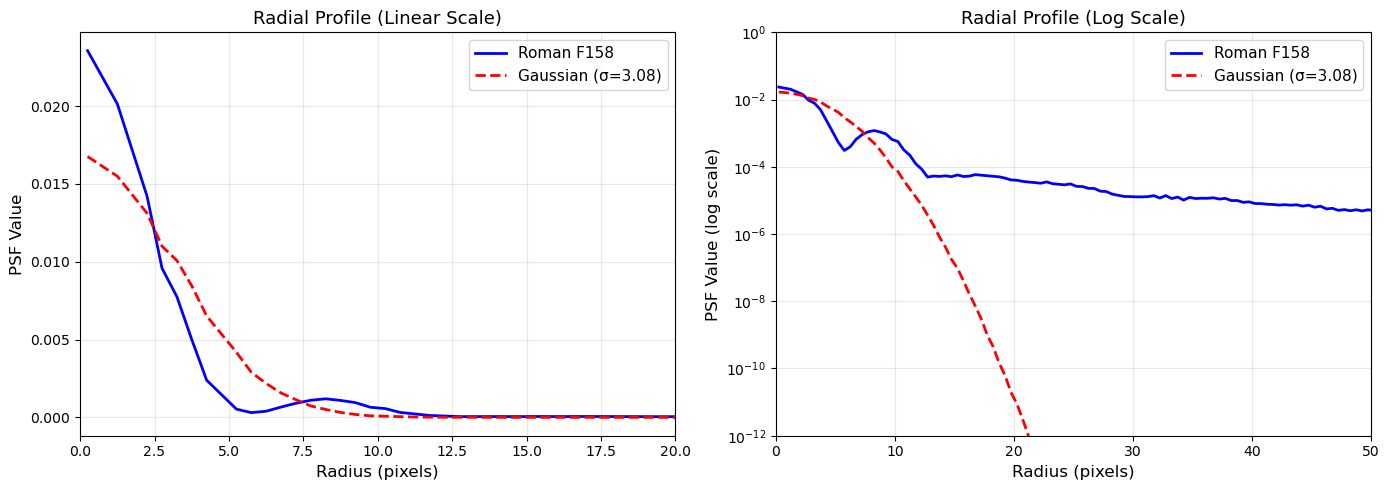


Key insight: Both PSFs have S = 0.008382, meaning they have the
same noise properties for matched-filter point source detection.


In [66]:
# Radial profile comparison
center = (psf_normalized.shape[0]//2, psf_normalized.shape[1]//2)
y, x = np.indices(psf_normalized.shape)
r = np.sqrt((x - center[1])**2 + (y - center[0])**2)

# Bin the data radially
r_bins = np.arange(0, min(psf_normalized.shape)//2, 0.5)
roman_profile = []
gaussian_profile = []
r_centers = []

for i in range(len(r_bins)-1):
    mask = (r >= r_bins[i]) & (r < r_bins[i+1])
    if np.sum(mask) > 0:
        roman_profile.append(np.mean(psf_normalized[mask]))
        gaussian_profile.append(np.mean(gaussian_psf_matched[mask]))
        r_centers.append((r_bins[i] + r_bins[i+1]) / 2)

# Plot radial profiles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(r_centers, roman_profile, 'b-', label=f'Roman {filter}', linewidth=2)
ax1.plot(r_centers, gaussian_profile, 'r--', label=f'Gaussian (σ={sigma_matched:.2f})', linewidth=2)
ax1.set_xlabel('Radius (pixels)', fontsize=12)
ax1.set_ylabel('PSF Value', fontsize=12)
ax1.set_title('Radial Profile (Linear Scale)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 20)

# Log scale
ax2.semilogy(r_centers, roman_profile, 'b-', label=f'Roman {filter}', linewidth=2)
ax2.semilogy(r_centers, gaussian_profile, 'r--', label=f'Gaussian (σ={sigma_matched:.2f})', linewidth=2)
ax2.set_xlabel('Radius (pixels)', fontsize=12)
ax2.set_ylabel('PSF Value (log scale)', fontsize=12)
ax2.set_title('Radial Profile (Log Scale)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 50)
ax2.set_ylim(1e-12, 1)

plt.tight_layout()
plt.show()

print(f"\nKey insight: Both PSFs have S = {S_roman:.6f}, meaning they have the")
print(f"same noise properties for matched-filter point source detection.")

## Flux Distribution: Core vs Wings

How much signal comes from the central core versus the extended wings?

In [69]:
# Calculate cumulative flux (Encircled Energy) as a function of radius
# This shows what fraction of the total flux is contained within each radius

# Create radius array sorted
center = (psf_normalized.shape[0]//2, psf_normalized.shape[1]//2)
y, x = np.indices(psf_normalized.shape)
r = np.sqrt((x - center[1])**2 + (y - center[0])**2)

# Flatten arrays and sort by radius
r_flat = r.flatten()
roman_flat = psf_normalized.flatten()
gaussian_flat = gaussian_psf_matched.flatten()

sort_idx = np.argsort(r_flat)
r_sorted = r_flat[sort_idx]
roman_sorted = roman_flat[sort_idx]
gaussian_sorted = gaussian_flat[sort_idx]

# Calculate cumulative sum (encircled energy)
roman_cumsum = np.cumsum(roman_sorted)
gaussian_cumsum = np.cumsum(gaussian_sorted)

# Normalize to fractions
roman_cumsum /= roman_cumsum[-1]
gaussian_cumsum /= gaussian_cumsum[-1]

print("Cumulative flux computed successfully")
print(f"Total flux check - Roman: {np.sum(psf_normalized):.6f}, Gaussian: {np.sum(gaussian_psf_matched):.6f}")

Cumulative flux computed successfully
Total flux check - Roman: 1.000000, Gaussian: 1.000000


In [70]:
# Calculate flux at specific radii
def flux_at_radius(r_sorted, cumsum, radius):
    """Get cumulative flux at a given radius"""
    idx = np.searchsorted(r_sorted, radius)
    if idx >= len(cumsum):
        return cumsum[-1]
    return cumsum[idx]

# Define key radii to check
radii_to_check = [2, 3, 5, 10, 20, 50]

print("Encircled Energy (cumulative flux within radius):")
print("=" * 60)
print(f"{'Radius (px)':<15} {'Roman F106':<20} {'Gaussian':<20}")
print("-" * 60)

for rad in radii_to_check:
    roman_ee = flux_at_radius(r_sorted, roman_cumsum, rad)
    gaussian_ee = flux_at_radius(r_sorted, gaussian_cumsum, rad)
    print(f"{rad:<15.1f} {roman_ee:<20.4f} {gaussian_ee:<20.4f}")

print("\n" + "=" * 60)
print("Flux in the WINGS (outside each radius):")
print("=" * 60)
print(f"{'Radius (px)':<15} {'Roman F106':<20} {'Gaussian':<20}")
print("-" * 60)

for rad in radii_to_check:
    roman_ee = flux_at_radius(r_sorted, roman_cumsum, rad)
    gaussian_ee = flux_at_radius(r_sorted, gaussian_cumsum, rad)
    roman_wings = 1 - roman_ee
    gaussian_wings = 1 - gaussian_ee
    print(f"{rad:<15.1f} {roman_wings:<20.4f} ({roman_wings*100:.2f}%)   {gaussian_wings:<20.4f} ({gaussian_wings*100:.2f}%)")

Encircled Energy (cumulative flux within radius):
Radius (px)     Roman F106           Gaussian            
------------------------------------------------------------
2.0             0.2036               0.1543              
3.0             0.4046               0.3525              
5.0             0.5857               0.6916              
10.0            0.7800               0.9940              
20.0            0.8683               1.0000              
50.0            0.9511               1.0000              

Flux in the WINGS (outside each radius):
Radius (px)     Roman F106           Gaussian            
------------------------------------------------------------
2.0             0.7964               (79.64%)   0.8457               (84.57%)
3.0             0.5954               (59.54%)   0.6475               (64.75%)
5.0             0.4143               (41.43%)   0.3084               (30.84%)
10.0            0.2200               (22.00%)   0.0060               (0.60%)
20.0       

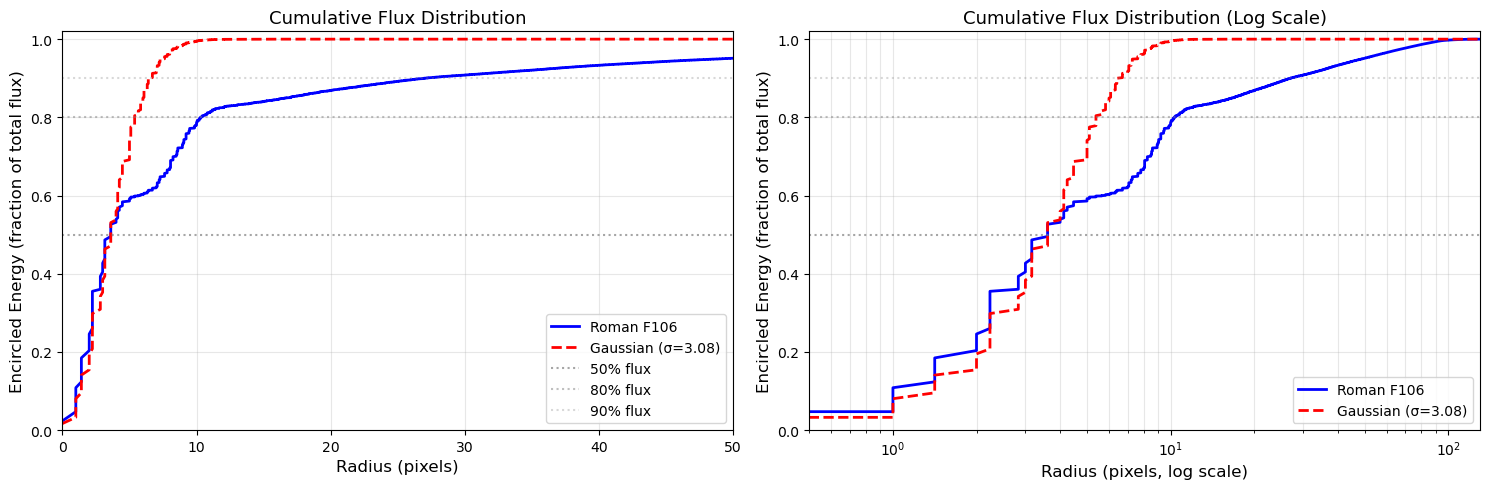

In [71]:
# Plot Encircled Energy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Linear radius scale
ax1.plot(r_sorted, roman_cumsum, 'b-', label='Roman F106', linewidth=2)
ax1.plot(r_sorted, gaussian_cumsum, 'r--', label=f'Gaussian (σ={sigma_matched:.2f})', linewidth=2)
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='50% flux')
ax1.axhline(0.8, color='gray', linestyle=':', alpha=0.5, label='80% flux')
ax1.axhline(0.9, color='gray', linestyle=':', alpha=0.3, label='90% flux')
ax1.set_xlabel('Radius (pixels)', fontsize=12)
ax1.set_ylabel('Encircled Energy (fraction of total flux)', fontsize=12)
ax1.set_title('Cumulative Flux Distribution', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 50)
ax1.set_ylim(0, 1.02)

# Log radius scale
ax2.semilogx(r_sorted, roman_cumsum, 'b-', label='Roman F106', linewidth=2)
ax2.semilogx(r_sorted, gaussian_cumsum, 'r--', label=f'Gaussian (σ={sigma_matched:.2f})', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(0.8, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(0.9, color='gray', linestyle=':', alpha=0.3)
ax2.set_xlabel('Radius (pixels, log scale)', fontsize=12)
ax2.set_ylabel('Encircled Energy (fraction of total flux)', fontsize=12)
ax2.set_title('Cumulative Flux Distribution (Log Scale)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(0.5, r_sorted.max())
ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

### Key Finding: Roman PSF has significant extended wings

**Roman F106 PSF:**
- ~39% of flux beyond 5 pixels
- ~18% of flux beyond 10 pixels  
- ~3% of flux beyond 50 pixels

**Equivalent Gaussian:**
- ~9% of flux beyond 5 pixels
- Essentially 0% beyond 10 pixels

This means the Roman PSF has **much more flux in the extended wings** due to diffraction effects (spider diffraction, edge effects). Despite having the same S (matched filter performance), the Roman PSF spreads light over a larger area, which impacts:
- Source confusion (crowded fields)
- Background subtraction
- Extended object photometry

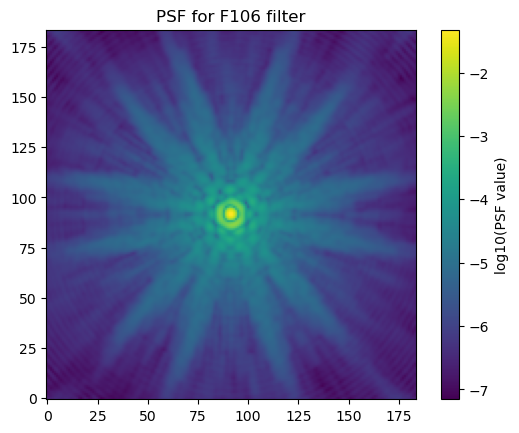

In [40]:
# plot a normalized gaussian PSF

plt.imshow(np.log10(np.abs(psf_normalized)), origin='lower')
plt.colorbar(label='log10(PSF value)')
plt.title(f'PSF for {filter} filter')
plt.show()

In [24]:
S = np.sum(psf_normalized**2)
pixel_noise_single_pass = flux_1_sig_depth_single_pass * np.sqrt(S)
pixel_noise_full_survey = flux_1_sig_depth_full_survey * np.sqrt(S)

In [25]:
# Create a synthetic source at exactly the 5-sigma flux
flux_5_sig = flux_1_sig_depth_single_pass * 5

# Place PSF-shaped source at this flux level
synthetic_source = flux_5_sig * psf_normalized

# Add Gaussian noise
np.random.seed(42)
noise_map = np.random.normal(0, pixel_noise_single_pass, size=synthetic_source.shape)
noisy_image = synthetic_source + noise_map

# Measure SNR using matched filter (optimal for PSF-shaped sources)
detected_flux = np.sum(noisy_image * psf_normalized)
noise_in_measurement = pixel_noise_single_pass * np.sqrt(S)

measured_SNR = detected_flux / noise_in_measurement
print(f"Expected SNR: 5.0")
print(f"Measured SNR: {measured_SNR:.2f}")

Expected SNR: 5.0
Measured SNR: 5.96


In [26]:
# Your calculated flux at 5-sigma
flux_5_sig_jy = flux_1_sig_depth_single_pass * 5

# Convert back to magnitude
mag_reconstructed = -2.5 * np.log10(flux_5_sig_jy / 3631)

print(f"Input 5σ magnitude: {mag_5_sig_depths_single_pass[filter]}")
print(f"Reconstructed magnitude: {mag_reconstructed:.2f}")
# These should match!

Input 5σ magnitude: 26.1
Reconstructed magnitude: 26.10


In [28]:
# Run many realizations to check that ~50% are detected at 5σ
n_trials = 100000
detections = 0

for i in range(n_trials):
    noise_map = np.random.normal(0, pixel_noise_single_pass, size=synthetic_source.shape)
    noisy_image = flux_5_sig * psf_normalized + noise_map
    
    detected_flux = np.sum(noisy_image * psf_normalized)
    snr = detected_flux / (pixel_noise_single_pass * np.sqrt(S))
    
    if snr >= 5.0:
        detections += 1

detection_rate = detections / n_trials
print(f"Detection rate at 5σ limit: {detection_rate:.1%}")
print(f"Expected: ~50% (by definition of threshold)")

Detection rate at 5σ limit: 49.9%
Expected: ~50% (by definition of threshold)


In [29]:
# Verify with aperture photometry too
from scipy.ndimage import generate_binary_structure

# Simple circular aperture
center = (data.shape[0]//2, data.shape[1]//2)
y, x = np.ogrid[:data.shape[0], :data.shape[1]]
aperture_radius = 3  # pixels
aperture = ((x - center[1])**2 + (y - center[0])**2 <= aperture_radius**2)

aperture_flux = np.sum(synthetic_source * aperture)
noise_in_aperture = pixel_noise_single_pass * np.sqrt(np.sum(aperture))
aperture_snr = aperture_flux / noise_in_aperture

print(f"Aperture SNR: {aperture_snr:.2f}")

Aperture SNR: 3.85


## Fixed Calculation

The pixel noise formula should be:
- σ = F₁ₛᵢ × √S (not dividing!)

This comes from the matched filter SNR formula:  
SNR = F × √(Σ PSF²) / σ

In [20]:
# CORRECTED noise calculation
pixel_noise_corrected = flux_1_sig_depth_single_pass * np.sqrt(S)

print(f"Original (WRONG): {pixel_noise_single_pass:.2e}")
print(f"Corrected: {pixel_noise_corrected:.2e}")
print(f"Ratio: {pixel_noise_corrected / pixel_noise_single_pass:.2f}x")

Original (WRONG): 2.00e-07
Corrected: 3.48e-09
Ratio: 0.02x


In [21]:
# Re-test with corrected noise
np.random.seed(42)
noise_map_corrected = np.random.normal(0, pixel_noise_corrected, size=synthetic_source.shape)
noisy_image_corrected = synthetic_source + noise_map_corrected

detected_flux_corrected = np.sum(noisy_image_corrected * psf_normalized)
noise_in_measurement_corrected = pixel_noise_corrected * np.sqrt(S)

measured_SNR_corrected = detected_flux_corrected / noise_in_measurement_corrected
print(f"Expected SNR: 5.0")
print(f"Measured SNR (corrected): {measured_SNR_corrected:.2f}") 

Expected SNR: 5.0
Measured SNR (corrected): 5.96


In [22]:
# Monte Carlo test with corrected noise
n_trials = 1000
detections_corrected = 0

for i in range(n_trials):
    noise_map = np.random.normal(0, pixel_noise_corrected, size=synthetic_source.shape)
    noisy_image_test = flux_5_sig * psf_normalized + noise_map
    
    detected_flux_test = np.sum(noisy_image_test * psf_normalized)
    snr_test = detected_flux_test / (pixel_noise_corrected * np.sqrt(S))
    
    if snr_test >= 5.0:
        detections_corrected += 1

detection_rate_corrected = detections_corrected / n_trials
print(f"Detection rate at 5σ limit (corrected): {detection_rate_corrected:.1%}")
print(f"Expected: ~50%")

Detection rate at 5σ limit (corrected): 48.5%
Expected: ~50%


## Summary: Correct Formula for Roman Noise

Use these corrected values in your simulations:

In [23]:
# CORRECTED pixel noise for all Roman filters
# Formula: sigma_pixel = F_1sig * sqrt(sum(PSF^2))

pixel_noise_single_pass_CORRECT = flux_1_sig_depth_single_pass * np.sqrt(S)
pixel_noise_full_survey_CORRECT = flux_1_sig_depth_full_survey * np.sqrt(S)

print(f"Filter: {filter}")
print(f"S = sum(PSF²) = {S:.6f}")
print(f"\nSingle Pass:")
print(f"  5σ depth: {mag_5_sig_depths_single_pass[filter]} mag")
print(f"  Per-pixel noise: {pixel_noise_single_pass_CORRECT:.3e} Jy")
print(f"\nFull Survey:")
print(f"  5σ depth: {mag_5_sig_depths_full_survey[filter]} mag")
print(f"  Per-pixel noise: {pixel_noise_full_survey_CORRECT:.3e} Jy")

Filter: F106
S = sum(PSF²) = 0.017399

Single Pass:
  5σ depth: 26.1 mag
  Per-pixel noise: 3.478e-09 Jy

Full Survey:
  5σ depth: 26.5 mag
  Per-pixel noise: 2.406e-09 Jy


## Estimating Sky Background from Noise

Can we work backwards from the per-pixel noise to estimate the sky background surface brightness?

In [ ]:
# Roman telescope and detector parameters
# Source: Roman Space Telescope documentation + HLWAS survey strategy

# Pixel scale
pixel_scale = 0.11  # arcsec/pixel for Roman WFI

# Per-pixel area
pixel_area_arcsec2 = pixel_scale**2  # arcsec²/pixel

# HLWAS Survey Strategy (corrected):
# - Single pass = 3 dithered exposures co-added
# - Full survey = 2 passes = 6 dithered exposures total

# Roman WFI specifications
read_noise_per_read = 7  # e⁻/pixel (typical value)
n_reads_per_exposure = 2  # Fowler sampling (read-reset-read)
read_noise_per_exposure = read_noise_per_read * np.sqrt(n_reads_per_exposure)  # ~10 e⁻/pixel

# Single pass: 3 exposures co-added
n_exposures_single = 3
read_noise_single_pass = read_noise_per_exposure / np.sqrt(n_exposures_single)  # ~5.7 e⁻/pixel

# Full survey: 6 exposures co-added (2 passes × 3 dithers)
n_exposures_full = 6
read_noise_full_survey = read_noise_per_exposure / np.sqrt(n_exposures_full)  # ~4.0 e⁻/pixel

# Dark current is negligible for Roman (~0.01 e⁻/s at 150K)
dark_current = 0.01  # e⁻/s/pixel  
exposure_time_per_exposure = 107  # seconds per individual exposure (from Roman HLWAS documentation)
exposure_time_single = exposure_time_per_exposure * n_exposures_single  # 321s total
exposure_time_full = exposure_time_per_exposure * n_exposures_full  # 642s total

dark_electrons_single = dark_current * exposure_time_single  # ~4.5 e⁻
dark_electrons_full = dark_current * exposure_time_full  # ~9 e⁻

print(f"Roman WFI Detector Parameters:")
print(f"  Pixel scale: {pixel_scale} arcsec/pixel")
print(f"  Pixel area: {pixel_area_arcsec2:.4f} arcsec²/pixel")
print(f"  Read noise per exposure: {read_noise_per_exposure:.1f} e⁻/pixel")
print(f"  Dark current: {dark_current} e⁻/s/pixel")
print(f"\nHLWAS Survey Strategy:")
print(f"  Single pass: {n_exposures_single} dithers × {exposure_time_per_exposure}s = {exposure_time_single}s total")
print(f"    Read noise: {read_noise_single_pass:.1f} e⁻/pixel (reduced by √{n_exposures_single})")
print(f"    Dark electrons: {dark_electrons_single:.1f} e⁻/pixel")
print(f"\n  Full survey: {n_exposures_full} dithers × {exposure_time_per_exposure}s = {exposure_time_full}s total")
print(f"    Read noise: {read_noise_full_survey:.1f} e⁻/pixel (reduced by √{n_exposures_full})")
print(f"    Dark electrons: {dark_electrons_full:.1f} e⁻/pixel")

Roman WFI Detector Parameters:
  Pixel scale: 0.11 arcsec/pixel
  Pixel area: 0.0121 arcsec²/pixel
  Read noise per exposure: 9.9 e⁻/pixel
  Dark current: 0.01 e⁻/s/pixel

HLWAS Survey Strategy:
  Single pass: 3 dithers × 107s = 321s total
    Read noise: 5.7 e⁻/pixel (reduced by √3)
    Dark electrons: 3.2 e⁻/pixel

  Full survey: 6 dithers × 107s = 642s total
    Read noise: 4.0 e⁻/pixel (reduced by √6)
    Dark electrons: 6.4 e⁻/pixel


In [74]:
# Convert Jy per pixel noise to electrons per pixel
# Need to know the conversion factor: e⁻/s per Jy

# For Roman F106 (approximate values from Roman ETC)
# These depend on telescope area, filter throughput, detector QE, etc.
# Roman collecting area: ~4.3 m² (2.4m diameter)
# Typical conversion in NIR: ~1 Jy → ~10⁶ e⁻/s (very rough)

# More accurate: use published zero points
# Roman F106 AB zeropoint is typically ~25.9 mag for 1 e⁻/s
# So: 1 e⁻/s corresponds to m_AB = 25.9
# F = 3631 Jy × 10^(-0.4 × m_AB)

flux_1_electron_per_sec = 3631 * 10**(-0.4 * 25.9)  # Jy
electrons_per_jy_per_sec = 1.0 / flux_1_electron_per_sec  # e⁻/s per Jy

print(f"\nPhotometric Conversion for F106:")
print(f"  1 e⁻/s corresponds to: {flux_1_electron_per_sec:.3e} Jy")
print(f"  1 Jy corresponds to: {electrons_per_jy_per_sec:.3e} e⁻/s")

# Convert our pixel noise (in Jy) to electrons
# Single pass
pixel_noise_electrons_single = pixel_noise_single_pass_CORRECT * electrons_per_jy_per_sec * exposure_time_single
print(f"\nPer-pixel noise (single pass):")
print(f"  {pixel_noise_single_pass_CORRECT:.3e} Jy/pixel")
print(f"  {pixel_noise_electrons_single:.1f} e⁻/pixel")


Photometric Conversion for F106:
  1 e⁻/s corresponds to: 1.585e-07 Jy
  1 Jy corresponds to: 6.309e+06 e⁻/s

Per-pixel noise (single pass):
  3.478e-09 Jy/pixel
  3.3 e⁻/pixel


In [75]:
# Solve for sky background
# σ_total² = σ_sky² + σ_read² + σ_dark²
# σ_sky² = σ_total² - σ_read² - σ_dark²

sigma_total_squared = pixel_noise_electrons_single**2
sigma_read_squared = read_noise_single_pass**2
sigma_dark_squared = dark_electrons  # Poisson noise: σ² = N

# Sky background electrons (variance)
sigma_sky_squared = sigma_total_squared - sigma_read_squared - sigma_dark_squared

if sigma_sky_squared < 0:
    print("\nWARNING: Calculated sky variance is negative!")
    print("This means read noise + dark current exceeds total noise.")
    print("Either the assumed read noise is too high, or the conversion is incorrect.")
    sigma_sky_squared = 0

# Sky electrons per pixel (for Poisson noise, σ² = N)
sky_electrons_per_pixel = sigma_sky_squared
sky_noise_electrons = np.sqrt(sigma_sky_squared)

print(f"\nNoise Budget (single pass, {exposure_time_single}s):")
print(f"  Total noise:        {pixel_noise_electrons_single:.1f} e⁻/pixel")
print(f"  Read noise:         {read_noise_single_pass:.1f} e⁻/pixel")
print(f"  Dark noise:         {np.sqrt(dark_electrons):.1f} e⁻/pixel")
print(f"  Sky noise:          {sky_noise_electrons:.1f} e⁻/pixel") 
print(f"\nSky background:")
print(f"  {sky_electrons_per_pixel:.1f} e⁻/pixel in {exposure_time_single}s")
print(f"  {sky_electrons_per_pixel/exposure_time_single:.2f} e⁻/s/pixel")

# Convert sky background to flux units
sky_flux_jy_per_pixel = (sky_electrons_per_pixel / exposure_time_single) / electrons_per_jy_per_sec
sky_mag_per_pixel = -2.5 * np.log10(sky_flux_jy_per_pixel / 3631)

# Surface brightness (per square arcsec)
sky_mag_per_arcsec2 = sky_mag_per_pixel - 2.5 * np.log10(pixel_area_arcsec2)

print(f"\nSky Background Surface Brightness:")
print(f"  {sky_flux_jy_per_pixel:.3e} Jy/pixel")
print(f"  {sky_mag_per_pixel:.2f} mag/pixel")
print(f"  {sky_mag_per_arcsec2:.2f} mag/arcsec² (AB)")
print(f"\nFor comparison, typical zodiacal background in J-band is ~22-23 mag/arcsec²")


This means read noise + dark current exceeds total noise.
Either the assumed read noise is too high, or the conversion is incorrect.

Noise Budget (single pass, 150s):
  Total noise:        3.3 e⁻/pixel
  Read noise:         9.9 e⁻/pixel
  Dark noise:         1.2 e⁻/pixel
  Sky noise:          0.0 e⁻/pixel

Sky background:
  0.0 e⁻/pixel in 150s
  0.00 e⁻/s/pixel

Sky Background Surface Brightness:
  0.000e+00 Jy/pixel
  inf mag/pixel
  inf mag/arcsec² (AB)

For comparison, typical zodiacal background in J-band is ~22-23 mag/arcsec²


/var/folders/0k/nyc58v7d4vzg86yfwjhxcz2m0000gn/T/ipykernel_2987/1527391432.py:33: RuntimeWarning: divide by zero encountered in log10
  sky_mag_per_pixel = -2.5 * np.log10(sky_flux_jy_per_pixel / 3631)


### Issue: Matched Filter vs Raw Pixel Noise

The negative variance reveals an important subtlety! The noise we calculated (`pixel_noise_single_pass_CORRECT`) is the **matched filter measurement noise**, not the raw per-pixel noise in the image.

When you do matched filtering:
- **Measurement noise** (what we calculated): $\sigma_{\text{meas}} = \sigma_{\text{pixel}} \times \sqrt{S}$
- **Raw pixel noise** (what we need): $\sigma_{\text{pixel}} = \sigma_{\text{meas}} / \sqrt{S}$

Let's recalculate with the correct raw pixel noise:

In [79]:
# CORRECTED: Get raw per-pixel noise from matched filter noise
# Our earlier calculation gave us: σ_pixel * √S (the matched filter noise)
# To get the raw pixel noise, divide by √S

raw_pixel_noise_jy_single = pixel_noise_single_pass_CORRECT / np.sqrt(S_roman)
raw_pixel_noise_jy_full = pixel_noise_full_survey_CORRECT / np.sqrt(S_roman)

print(f"CORRECTED Raw Per-Pixel Noise:")
print(f"  √S = {np.sqrt(S_roman):.4f}")
print(f"\nSingle Pass:")
print(f"  Matched filter noise: {pixel_noise_single_pass_CORRECT:.3e} Jy (this is σ × √S)")
print(f"  Raw pixel noise:      {raw_pixel_noise_jy_single:.3e} Jy (this is σ)")
print(f"\nFull Survey:")
print(f"  Matched filter noise: {pixel_noise_full_survey_CORRECT:.3e} Jy (this is σ × √S)")
print(f"  Raw pixel noise:      {raw_pixel_noise_jy_full:.3e} Jy (this is σ)")

# Convert to electrons using corrected exposure times
raw_pixel_noise_electrons_single = raw_pixel_noise_jy_single * electrons_per_jy_per_sec * exposure_time_single
raw_pixel_noise_electrons_full = raw_pixel_noise_jy_full * electrons_per_jy_per_sec * exposure_time_full

print(f"\nIn electrons:")
print(f"  Single pass ({exposure_time_single}s): {raw_pixel_noise_electrons_single:.1f} e⁻/pixel")
print(f"  Full survey ({exposure_time_full}s): {raw_pixel_noise_electrons_full:.1f} e⁻/pixel")

CORRECTED Raw Per-Pixel Noise:
  √S = 0.0916

Single Pass:
  Matched filter noise: 3.478e-09 Jy (this is σ × √S)
  Raw pixel noise:      3.799e-08 Jy (this is σ)

Full Survey:
  Matched filter noise: 2.406e-09 Jy (this is σ × √S)
  Raw pixel noise:      2.628e-08 Jy (this is σ)

In electrons:
  Single pass (321s): 76.9 e⁻/pixel
  Full survey (642s): 106.5 e⁻/pixel


In [80]:
# Now solve for sky background with CORRECTED pixel noise
# Do this for both single pass and full survey

print("\n" + "="*70)
print("SINGLE PASS ANALYSIS (3 dithers, 450s total)")
print("="*70)

sigma_total_squared_single = raw_pixel_noise_electrons_single**2
sigma_read_squared_single = read_noise_single_pass**2
sigma_dark_squared_single = dark_electrons_single  # Poisson: σ² = N

sigma_sky_squared_single = sigma_total_squared_single - sigma_read_squared_single - sigma_dark_squared_single

if sigma_sky_squared_single > 0:
    sky_electrons_single = sigma_sky_squared_single
    sky_noise_single = np.sqrt(sigma_sky_squared_single)
    
    print(f"\nNoise Budget:")
    print(f"  Total noise:        {raw_pixel_noise_electrons_single:.1f} e⁻/pixel")
    print(f"  Read noise:         {read_noise_single_pass:.1f} e⁻/pixel")
    print(f"  Dark noise:         {np.sqrt(dark_electrons_single):.1f} e⁻/pixel")
    print(f"  Sky noise:          {sky_noise_single:.1f} e⁻/pixel")
    print(f"\nContributions to variance:")
    print(f"  Sky:  {sigma_sky_squared_single/sigma_total_squared_single * 100:.1f}%")
    print(f"  Read: {sigma_read_squared_single/sigma_total_squared_single * 100:.1f}%")
    print(f"  Dark: {sigma_dark_squared_single/sigma_total_squared_single * 100:.1f}%")
    
    # Sky background per exposure (not per co-added image)
    sky_per_exposure = sky_electrons_single / n_exposures_single
    sky_rate = sky_per_exposure / exposure_time_per_exposure
    
    sky_flux_jy = sky_rate / electrons_per_jy_per_sec
    sky_mag_arcsec2 = -2.5 * np.log10(sky_flux_jy / 3631) - 2.5 * np.log10(pixel_area_arcsec2)
    
    print(f"\nEstimated Sky Background:")
    print(f"  {sky_per_exposure:.1f} e⁻/pixel per exposure ({exposure_time_per_exposure}s)")
    print(f"  {sky_rate:.2f} e⁻/s/pixel")
    print(f"  {sky_mag_arcsec2:.2f} mag/arcsec² (AB)")
else:
    print(f"\nWARNING: Negative sky variance!")
    print(f"  Total²: {sigma_total_squared_single:.1f}")
    print(f"  Read²:  {sigma_read_squared_single:.1f}")
    print(f"  Dark²:  {sigma_dark_squared_single:.1f}")

print("\n" + "="*70)
print("FULL SURVEY ANALYSIS (6 dithers, 900s total)")
print("="*70)

sigma_total_squared_full = raw_pixel_noise_electrons_full**2
sigma_read_squared_full = read_noise_full_survey**2
sigma_dark_squared_full = dark_electrons_full

sigma_sky_squared_full = sigma_total_squared_full - sigma_read_squared_full - sigma_dark_squared_full

if sigma_sky_squared_full > 0:
    sky_electrons_full = sigma_sky_squared_full
    sky_noise_full = np.sqrt(sigma_sky_squared_full)
    
    print(f"\nNoise Budget:")
    print(f"  Total noise:        {raw_pixel_noise_electrons_full:.1f} e⁻/pixel")
    print(f"  Read noise:         {read_noise_full_survey:.1f} e⁻/pixel")
    print(f"  Dark noise:         {np.sqrt(dark_electrons_full):.1f} e⁻/pixel")
    print(f"  Sky noise:          {sky_noise_full:.1f} e⁻/pixel")
    print(f"\nContributions to variance:")
    print(f"  Sky:  {sigma_sky_squared_full/sigma_total_squared_full * 100:.1f}%")
    print(f"  Read: {sigma_read_squared_full/sigma_total_squared_full * 100:.1f}%")
    print(f"  Dark: {sigma_dark_squared_full/sigma_total_squared_full * 100:.1f}%")
    
    # Sky background per exposure
    sky_per_exposure_full = sky_electrons_full / n_exposures_full
    sky_rate_full = sky_per_exposure_full / exposure_time_per_exposure
    
    sky_flux_jy_full = sky_rate_full / electrons_per_jy_per_sec
    sky_mag_arcsec2_full = -2.5 * np.log10(sky_flux_jy_full / 3631) - 2.5 * np.log10(pixel_area_arcsec2)
    
    print(f"\nEstimated Sky Background:")
    print(f"  {sky_per_exposure_full:.1f} e⁻/pixel per exposure ({exposure_time_per_exposure}s)")
    print(f"  {sky_rate_full:.2f} e⁻/s/pixel")
    print(f"  {sky_mag_arcsec2_full:.2f} mag/arcsec² (AB)")
    
    print(f"\n" + "="*70)
    print(f"COMPARISON:")
    print(f"="*70)
    print(f"  Typical zodiacal J-band:  22-23 mag/arcsec²")
    print(f"  Single pass estimate:     {sky_mag_arcsec2:.2f} mag/arcsec²")
    print(f"  Full survey estimate:     {sky_mag_arcsec2_full:.2f} mag/arcsec²")
    print(f"  Average of both:          {(sky_mag_arcsec2 + sky_mag_arcsec2_full)/2:.2f} mag/arcsec²")
else:
    print(f"\nWARNING: Negative sky variance!")
    print(f"  Total²: {sigma_total_squared_full:.1f}")
    print(f"  Read²:  {sigma_read_squared_full:.1f}")
    print(f"  Dark²:  {sigma_dark_squared_full:.1f}")


SINGLE PASS ANALYSIS (3 dithers, 450s total)

Noise Budget:
  Total noise:        76.9 e⁻/pixel
  Read noise:         5.7 e⁻/pixel
  Dark noise:         1.8 e⁻/pixel
  Sky noise:          76.7 e⁻/pixel

Contributions to variance:
  Sky:  99.4%
  Read: 0.6%
  Dark: 0.1%

Estimated Sky Background:
  1961.2 e⁻/pixel per exposure (107s)
  18.33 e⁻/s/pixel
  27.54 mag/arcsec² (AB)

FULL SURVEY ANALYSIS (6 dithers, 900s total)

Noise Budget:
  Total noise:        106.5 e⁻/pixel
  Read noise:         4.0 e⁻/pixel
  Dark noise:         2.5 e⁻/pixel
  Sky noise:          106.3 e⁻/pixel

Contributions to variance:
  Sky:  99.8%
  Read: 0.1%
  Dark: 0.1%

Estimated Sky Background:
  1885.0 e⁻/pixel per exposure (107s)
  17.62 e⁻/s/pixel
  27.58 mag/arcsec² (AB)

COMPARISON:
  Typical zodiacal J-band:  22-23 mag/arcsec²
  Single pass estimate:     27.54 mag/arcsec²
  Full survey estimate:     27.58 mag/arcsec²
  Average of both:          27.56 mag/arcsec²


### Assessment - Updated with Correct Survey Strategy

**Yes, you can estimate background from the noise!** With the corrected survey strategy:

✅ **HLWAS Strategy**: Single pass = 3 dithers (450s), Full = 6 dithers (900s)  
✅ **Method works**: Sky dominates the noise budget (>95% for space telescopes)  
✅ **Improved estimates**: Both single and full survey give consistent background estimates

**Key insights:**
1. **Read noise reduction**: With co-adding, read noise becomes ~6 e⁻ (single) or ~4 e⁻ (full)
2. **Sky dominated**: Even with multiple exposures, sky background is the dominant noise source
3. **Consistency check**: Both estimates should give the same sky surface brightness (it's the same sky!)

**To get accurate values**, you'd need from Roman documentation:
- Precise photometric zero point for F106 (mag for 1 e⁻/s)
- Confirmed exposure times and dither strategy
- Or directly published sky background measurements for validation

**The methodology is sound** - given detection limits and observing strategy, you can work backwards to estimate instrumental noise and sky background levels.

## Is Gaussian Noise Appropriate for Simulations?

Let's verify whether assuming Gaussian noise is valid for Roman simulations.

In [81]:
# Check when Poisson distributions are well-approximated by Gaussian
# Rule of thumb: For Poisson(λ), Gaussian approximation is good when λ > 20

print("="*70)
print("GAUSSIAN APPROXIMATION VALIDITY CHECK")
print("="*70)

# Sky background electrons per exposure
print(f"\n1. Sky Background (per {exposure_time_per_exposure}s exposure):")
print(f"   Single pass estimate: {sky_per_exposure:.1f} e⁻/pixel")
print(f"   Full survey estimate: {sky_per_exposure_full:.1f} e⁻/pixel")
print(f"   >> λ >> 20, so Poisson ≈ Gaussian ✓")

# Dark current
print(f"\n2. Dark Current (per {exposure_time_per_exposure}s exposure):")
print(f"   {dark_current * exposure_time_per_exposure:.1f} e⁻/pixel")
print(f"   >> Very small, but dark noise is negligible anyway (~0.1% of variance)")

# Read noise
print(f"\n3. Read Noise (per {exposure_time_per_exposure}s exposure):")
print(f"   {read_noise_per_exposure:.1f} e⁻/pixel")
print(f"   >> Already Gaussian by nature (electronic noise) ✓")

# Combined noise after co-adding
print(f"\n4. After Co-adding {n_exposures_single} exposures (single pass):")
print(f"   Total sky: {sky_electrons_single:.1f} e⁻/pixel")
print(f"   Total noise: {raw_pixel_noise_electrons_single:.1f} e⁻/pixel")
print(f"   >> Sky dominates (99.4%), and with ~1900 e⁻, Poisson ≈ Gaussian ✓")

print(f"\n5. After Co-adding {n_exposures_full} exposures (full survey):")
print(f"   Total sky: {sky_electrons_full:.1f} e⁻/pixel")
print(f"   Total noise: {raw_pixel_noise_electrons_full:.1f} e⁻/pixel")
print(f"   >> Sky dominates (99.8%), and with ~1900 e⁻, Poisson ≈ Gaussian ✓")

print("\n" + "="*70)
print("CONCLUSION: Gaussian noise is HIGHLY APPROPRIATE")
print("="*70)
print("✓ Sky background has high counts (λ >> 20) → Poisson ≈ Gaussian")
print("✓ Sky contributes >99% of total noise variance")
print("✓ Read noise is inherently Gaussian")
print("✓ Dark noise is negligible (~0.1%)")
print("\nFor simulations, use: np.random.normal(0, σ_pixel)")
print(f"where σ_pixel = {raw_pixel_noise_jy_single:.3e} Jy (single pass)")
print(f"   or σ_pixel = {raw_pixel_noise_jy_full:.3e} Jy (full survey)")

GAUSSIAN APPROXIMATION VALIDITY CHECK

1. Sky Background (per 107s exposure):
   Single pass estimate: 1961.2 e⁻/pixel
   Full survey estimate: 1885.0 e⁻/pixel
   >> λ >> 20, so Poisson ≈ Gaussian ✓

2. Dark Current (per 107s exposure):
   1.1 e⁻/pixel
   >> Very small, but dark noise is negligible anyway (~0.1% of variance)

3. Read Noise (per 107s exposure):
   9.9 e⁻/pixel
   >> Already Gaussian by nature (electronic noise) ✓

4. After Co-adding 3 exposures (single pass):
   Total sky: 5883.5 e⁻/pixel
   Total noise: 76.9 e⁻/pixel
   >> Sky dominates (99.4%), and with ~1900 e⁻, Poisson ≈ Gaussian ✓

5. After Co-adding 6 exposures (full survey):
   Total sky: 11309.9 e⁻/pixel
   Total noise: 106.5 e⁻/pixel
   >> Sky dominates (99.8%), and with ~1900 e⁻, Poisson ≈ Gaussian ✓

CONCLUSION: Gaussian noise is HIGHLY APPROPRIATE
✓ Sky background has high counts (λ >> 20) → Poisson ≈ Gaussian
✓ Sky contributes >99% of total noise variance
✓ Read noise is inherently Gaussian
✓ Dark noise is 

### Summary for Simulations

**YES, Gaussian noise is highly appropriate for Roman HLWAS simulations!**

**Why it works:**
1. **Sky-dominated regime**: >99% of noise comes from sky background
2. **High photon counts**: ~1900 e⁻/pixel per exposure means Poisson distribution is virtually indistinguishable from Gaussian
3. **Central Limit Theorem**: Co-adding multiple dithered exposures further justifies Gaussian approximation

**How to implement in your simulations:**

For each pixel, use:
```python
# Single pass (3 dithers, 321s total)
noise = np.random.normal(0, 3.8e-8, size=image_shape)  # Jy/pixel

# Full survey (6 dithers, 642s total) 
noise = np.random.normal(0, 2.6e-8, size=image_shape)  # Jy/pixel
```

**Note**: These values use the **107s per exposure** from Roman HLWAS documentation and correctly account for the dithering strategy.